# Atoms data checker

Check for outlier forces and energies

In [16]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
import pandas as pd
import ast
import time
from sklearn.model_selection import train_test_split

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [17]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / '../data'

SEED = 42
torch.manual_seed(SEED)

# Load base dataset
BASE_XYZ = DATA_DIR / 'A02_propene_grid_static_CASSCF.xyz'
BASE_N_GEOMETRIES = '3731' 
base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")

# Load transfer dataset
TRANSFER_XYZ = DATA_DIR / "A02_propene_grid_static_NEVPT2.xyz"
TRANSFER_N_GEOMETRIES = '3731'
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")


In [ ]:
def _get_field(atoms, key):
    if key in atoms.info:
        value = atoms.info[key]
    elif key in atoms.arrays:
        value = atoms.arrays[key]
    else:
        available = sorted(list(atoms.info.keys()) + list(atoms.arrays.keys()))
        raise KeyError(f"{key} not found in atoms.info or atoms.arrays. Available keys: {available}")
    return np.asarray(value)


def max_force_per_atom(atoms_list):
    max_forces = []
    for atoms in atoms_list:
        forces = _get_field(atoms, "REF_forces")
        if forces.shape != (9,3,3): # propene has 9 atoms
            raise ValueError(f"Unexpected REF_forces shape: {forces.shape}")
        max_forces.append(np.max(np.abs(forces)))
    return max_forces


def max_energy_per_atom(atoms_list):
    max_energies = []
    for atoms in atoms_list:
        energy = _get_field(atoms, "REF_energy")
        if energy.size == 0:
            raise ValueError("REF_energy is empty")
        max_energies.append(float(np.max(energy.reshape(-1))))
    return max_energies


First structure info keys: ['REF_energy', 'REF_forces']
First structure arrays keys: ['numbers', 'positions']
14.952566285338674
-3185.852360941542


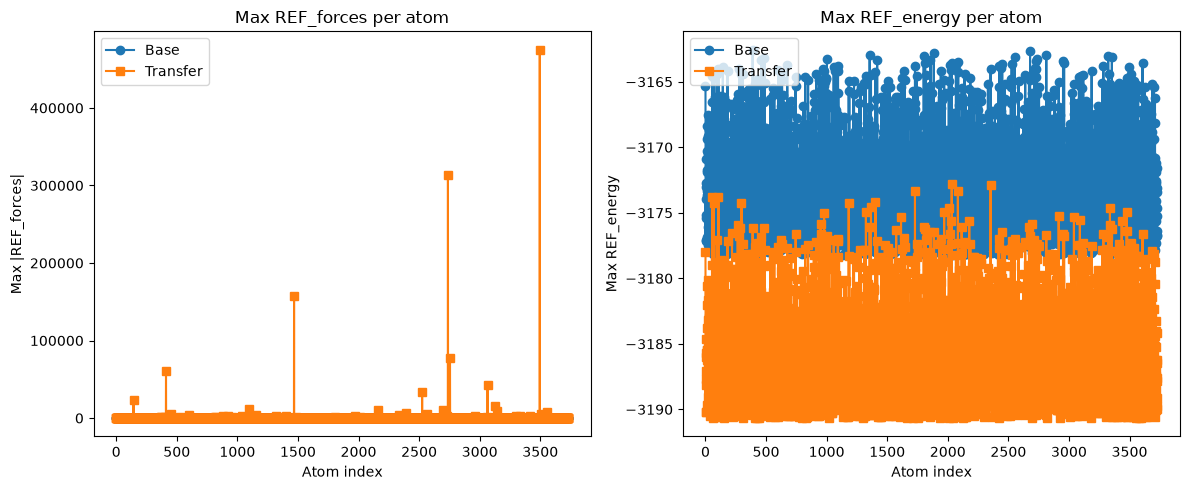

In [ ]:
# Debug: print the available metadata keys on the first structure.
if len(base_atoms_list) > 0:
    first_atoms = base_atoms_list[0]
    print("First structure info keys:", sorted(first_atoms.info.keys()))
    print("First structure arrays keys:", sorted(first_atoms.arrays.keys()))

# Find max forces and energies
base_max_forces = max_force_per_atom(base_atoms_list)
transfer_max_forces = max_force_per_atom(transfer_atoms_list)

base_max_energy = max_energy_per_atom(base_atoms_list)
transfer_max_energy = max_energy_per_atom(transfer_atoms_list)

# Plot
base_indices = np.arange(len(base_max_forces))
transfer_indices = np.arange(len(transfer_max_forces))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(base_indices, base_max_forces, marker="o", label="Base")
plt.plot(transfer_indices, transfer_max_forces, marker="s", label="Transfer")
plt.xlabel("Atom index")
plt.ylabel("Max |REF_forces|")
plt.title("Max REF_forces per atom")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(base_indices, base_max_energy, marker="o", label="Base")
plt.plot(transfer_indices, transfer_max_energy, marker="s", label="Transfer")
plt.xlabel("Atom index")
plt.ylabel("Max REF_energy")
plt.title("Max REF_energy per atom")
plt.legend()

plt.tight_layout()
plt.show()
